In [386]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Note: AI was used to help asist in this creating this notebook to help understand how to determine how to handle the multimodal datasets and how to handle the overlapping primary keys within collisionID

Creating Dummy Features

In [350]:
crash_roads_data = pd.read_csv('crash_data_roads.csv')
crash_parties_background_data = pd.read_csv('crash_parties_background_info.csv')
crash_parties_car_data = pd.read_csv('crash_parties_car_data.csv')
crash_parties_speed_limit_data = pd.read_csv('crash_parties_speed_limit_data.csv')
crash_data_freeway = pd.read_csv('freeway_crashes.csv') #This and local might be redundant
crash_data_local = pd.read_csv('local_crashes.csv')
crash_data_collision_factors = pd.read_csv('main_collision_factors.csv')
crash_roads_speed_limit_data = pd.merge(crash_roads_data, crash_parties_speed_limit_data, on='CollisionId', how='inner')
crash_parties_car_background_data = pd.merge(crash_parties_car_data, crash_parties_background_data, on='CollisionId', how='inner')
crash_parties_car_collision_background = pd.merge(crash_parties_car_background_data, crash_data_collision_factors, on='CollisionId', how='inner')



Divide the features and determine what features to use

In [351]:
crash_parties_background_data.head()

,CollisionId,PartyType,Special Information,IsAtFault
0,4541902,Driver,CELL PHONE USE UNKNOWN,True
1,4541901,Driver,CELL PHONE NOT IN USE,False
2,4541901,Driver,CELL PHONE USE UNKNOWN,True
3,4541900,Driver,CELL PHONE NOT IN USE,False
4,4541900,Driver,CELL PHONE NOT IN USE,False


In [352]:
crash_parties_car_collision_background["Vehicle1Model"].value_counts()

Vehicle1Model
CAMRY              50174
CIVIC              49089
ACCORD             46361
COROLLA            38942
SILVERADO          24754
                   ...  
SIENNA SYMPHONY        1
TVL                    1
ESCORT SE              1
SLINE                  1
200CC                  1
Name: count, Length: 12469, dtype: int64

In [353]:
top_models = crash_parties_car_collision_background["Vehicle1Model"].value_counts().head(15).index
crash_parties_car_collision_background.loc[~crash_parties_car_collision_background['Vehicle1Model'].isin(top_models), 'Vehicle1Model'] = 'Other'
crash_parties_car_collision_background = crash_parties_car_collision_background[crash_parties_car_collision_background['Vehicle1Model'].isin(top_models)]

In [354]:
crash_parties_car_collision_background['Vehicle1Model'].value_counts()

Vehicle1Model
CAMRY        50174
CIVIC        49089
ACCORD       46361
COROLLA      38942
SILVERADO    24754
PRIUS        24250
TACOMA       23974
RAV4         20751
ALTIMA       18715
CRV          18120
MODEL 3      15722
F-150        13961
SENTRA       13815
MODEL Y      13407
RAM 1500     11302
Name: count, dtype: int64

In [355]:
top_10_colors = crash_parties_car_collision_background["Vehicle1Color"].value_counts().head(10).index
crash_parties_car_collision_background = crash_parties_car_collision_background[crash_parties_car_collision_background['Vehicle1Color'].isin(top_10_colors)]

In [356]:
#top_10_makes = crash_parties_car_collision_background["Vehicle1Make"].value_counts().head(10).index
#crash_parties_car_collision_background = crash_parties_car_collision_background[crash_parties_car_collision_background['Vehicle1Make'].isin(top_10_makes)]

In [357]:
crash_parties_car_collision_background[['IsAtFault', 'IsTowAway']] = crash_parties_car_collision_background[['IsAtFault', 'IsTowAway']].astype(int)

In [358]:
crash_parties_car_collision_background.columns

Index(['CollisionId', 'Vehicle1Year', 'Vehicle1Make', 'Vehicle1Model',
       'Vehicle1Color', 'V1IsVehicleTowed', 'PartyType', 'Special Information',
       'IsAtFault', 'IsTowAway', 'MotorVehicleInvolvedWithDesc',
       'NumberInjured', 'NumberKilled', 'Primary Collision Factor Code',
       'Primary Collision Factor Violation', 'PrimaryCollisionFactorIsCited',
       'PrimaryCollisionPartyNumber', 'parsed_values'],
      dtype='str')

In [359]:
crash_parties_car_collision_background['Vehicle1Color'].value_counts()

Vehicle1Color
White     98215
Gray      83001
Black     61678
Silver    54393
Blue      29610
Red       24347
Green      5626
Gold       4927
TAN        3811
MAR        2162
Name: count, dtype: int64

In [360]:
crash_parties_car_collision_background['Vehicle1Make'].value_counts()

Vehicle1Make
TOYOTA       151193
HONDA        109415
NISSAN        31437
TESLA         28254
CHEVROLET     23467
FORD          13275
RAM           10726
Name: count, dtype: int64

In [361]:
crash_parties_car_collision_background[crash_parties_car_collision_background['Vehicle1Make'] == 'VNHO']

,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,PartyType,Special Information,IsAtFault,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,NumberKilled,Primary Collision Factor Code,Primary Collision Factor Violation,PrimaryCollisionFactorIsCited,PrimaryCollisionPartyNumber,parsed_values


In [362]:
speeding = crash_parties_car_collision_background.loc[crash_parties_car_collision_background['parsed_values'] == 22350.0]
lane_change = crash_parties_car_collision_background.loc[crash_parties_car_collision_background['parsed_values'] == 22107.0]

combined_traffic_violations = set(speeding) | set(lane_change)

In [363]:
crash_parties_car_collision_background['speeding'] = np.where(crash_parties_car_collision_background['parsed_values'] == 22350.0, True, False)
crash_parties_car_collision_background['unsafe_lane_change'] = np.where(crash_parties_car_collision_background['parsed_values'] == 22107.0, True,False)

In [364]:
crash_parties_car_collision_background['speeding'].value_counts()

speeding
False    211632
True     156138
Name: count, dtype: int64

In [365]:
crash_parties_car_collision_background['unsafe_lane_change'].value_counts()

unsafe_lane_change
False    307562
True      60208
Name: count, dtype: int64

In [366]:
crash_parties_car_collision_background.drop(['Primary Collision Factor Code', 'Primary Collision Factor Violation', 'PrimaryCollisionPartyNumber', 'PrimaryCollisionFactorIsCited','Special Information', 'MotorVehicleInvolvedWithDesc', 'parsed_values'], axis = 1, inplace = True)

In [367]:
crash_parties_car_collision_background_dummies = pd.get_dummies(crash_parties_car_collision_background, columns = ['PartyType', 'speeding', 'unsafe_lane_change'], dtype = int)

In [368]:
crash_parties_car_collision_background_dummies.columns

Index(['CollisionId', 'Vehicle1Year', 'Vehicle1Make', 'Vehicle1Model',
       'Vehicle1Color', 'V1IsVehicleTowed', 'IsAtFault', 'IsTowAway',
       'NumberInjured', 'NumberKilled', 'PartyType_Bicyclist',
       'PartyType_Driver', 'PartyType_Operator', 'PartyType_Other',
       'PartyType_ParkedVehicle', 'PartyType_Pedestrian', 'speeding_False',
       'speeding_True', 'unsafe_lane_change_False', 'unsafe_lane_change_True'],
      dtype='str')

In [369]:
crash_parties_car_collision_background_dummies.head()

,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,IsAtFault,IsTowAway,NumberInjured,NumberKilled,PartyType_Bicyclist,PartyType_Driver,PartyType_Operator,PartyType_Other,PartyType_ParkedVehicle,PartyType_Pedestrian,speeding_False,speeding_True,unsafe_lane_change_False,unsafe_lane_change_True
0,4541901,2005.0,FORD,F-150,Gray,True,0,1,1.0,0.0,0,1,0,0,0,0,1,0,1,0
1,4541901,2005.0,FORD,F-150,Gray,True,1,1,1.0,0.0,0,1,0,0,0,0,1,0,1,0
10,4541896,2012.0,TOYOTA,COROLLA,Black,False,0,0,0.0,0.0,0,1,0,0,0,0,0,1,1,0
11,4541896,2012.0,TOYOTA,COROLLA,Black,False,1,0,0.0,0.0,0,1,0,0,0,0,0,1,1,0
12,4541895,2017.0,HONDA,CIVIC,Blue,False,0,0,0.0,0.0,0,1,0,0,0,0,1,0,1,0


Split Data

For splitting the data, to make it simple, we should just classify who is more likely to cause an accident rather than who will get injured or killed since most of the time its 0. We need to use groupshufflesplit here since there are many different values related to each other via collisionID we need to use this so that there is no data leaks

In [370]:
X = crash_parties_car_collision_background_dummies.drop(columns = ['CollisionId', 'IsAtFault'])
y = crash_parties_car_collision_background_dummies['IsAtFault']
groups = crash_parties_car_collision_background_dummies['CollisionId']


In [371]:
X['V1IsVehicleTowed'] = X['V1IsVehicleTowed'].fillna(False)

In [372]:
numeric_features = ['NumberInjured', 'NumberKilled', 'Vehicle1Year']
categorical_features = ['Vehicle1Make', 'Vehicle1Model', 'Vehicle1Color']
boolean_features = ['V1IsVehicleTowed','IsTowAway','PartyType_Bicyclist','PartyType_Driver','PartyType_Operator','PartyType_Other','PartyType_ParkedVehicle','PartyType_Pedestrian','unsafe_lane_change_False','unsafe_lane_change_True','speeding_False','speeding_True']

In [373]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [374]:
#Determine if the groupshuffle split didnt lead into any data leaks between the training and testing sets
train_users = set(crash_parties_car_collision_background_dummies.iloc[train_idx]['CollisionId'])
test_users = set(crash_parties_car_collision_background_dummies.iloc[test_idx]['CollisionId'])
print(f"Overlap in users: {train_users.intersection(test_users)}")  # Will print set()

Overlap in users: set()


Scale Standarization

For the standardization, we need to split the dataset temporairly to scale and then rejoin them after

In [375]:
X_train.isna().sum() #Found out that there was some nan values in V1isTowAway

Vehicle1Year                0
Vehicle1Make                3
Vehicle1Model               0
Vehicle1Color               0
V1IsVehicleTowed            0
IsTowAway                   0
NumberInjured               0
NumberKilled                0
PartyType_Bicyclist         0
PartyType_Driver            0
PartyType_Operator          0
PartyType_Other             0
PartyType_ParkedVehicle     0
PartyType_Pedestrian        0
speeding_False              0
speeding_True               0
unsafe_lane_change_False    0
unsafe_lane_change_True     0
dtype: int64

In [376]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ]
)

Logistic Regression Model

Penalty set to default

In [382]:
C_param_range = [.001,.01,.1,1,10,100,1000]
logistic_table = pd.DataFrame(columns = ['C_parameter','Accuracy'])
logistic_table['C_parameter'] = C_param_range

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('Logistic_Regressor', LogisticRegression(max_iter= 1000, random_state= 42))
])

param_grid = {
    'Logistic_Regressor__C': C_param_range, 
    'Logistic_Regressor__solver': ['saga']
}

grid_search = GridSearchCV(
    estimator= model_pipeline, 
    param_grid= param_grid,
    cv = 5, 
    scoring= 'accuracy',
    n_jobs = -1
)

grid_search.fit(X_train,y_train)

best_pipeline = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'Logistic_Regressor__C': 1, 'Logistic_Regressor__solver': 'saga'}


In [392]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('LogisticRegressor', LogisticRegression(C = 1, solver = 'saga', random_state= 42))
])

model_pipeline.fit(X_train, y_train)
train_accuracy = model_pipeline.score(X_train,y_train)
accuracy = model_pipeline.score(X_test,y_test)
print(train_accuracy)
print(accuracy)

c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.591939194230291
0.5898248600872983


<Figure size 600x600 with 0 Axes>

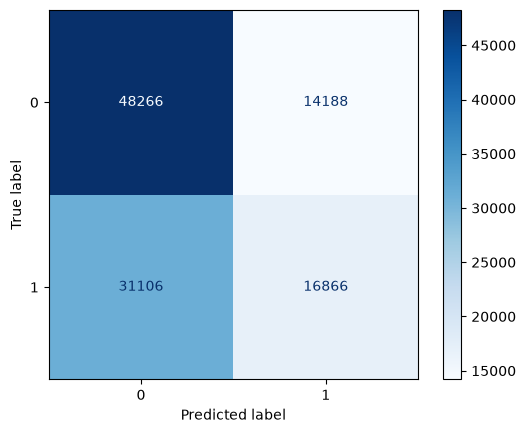

In [387]:
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    grid_search,      # Your fitted GridSearchCV or Pipeline object
    X_test, 
    y_test,
    cmap='Blues',     # Color map palette
    normalize=None    # Set to 'true' for proportions instead of raw counts
)

In [394]:
accuracy = model_pipeline.score(X_test,y_test)
print("Pipeline Accuracy: ", accuracy)

Pipeline Accuracy:  0.5898248600872983


In [393]:
cv_scores_test= cross_val_score(model_pipeline,X_test,y_test,cv=5,scoring='roc_auc')
cv_scores_train= cross_val_score(model_pipeline,X_train,y_train,cv=5,scoring='roc_auc')
print(cv_scores_test)
cv_scores_rf_test= cv_scores_test.mean()
cv_scores_rf_train= cv_scores_train.mean()
cv_scores_std_rf= cv_scores_test.std()
print ('Mean cross validation test score: ' +str(cv_scores_rf_test))
print ('Mean cross validation train score: ' +str(cv_scores_rf_train))
print ('Standard deviation in cv scores: ' +str(cv_scores_std_rf))

c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\P

[0.61437906 0.62322876 0.62155089 0.62192354 0.63344696]
Mean cross validation test score: 0.6229058427654666
Mean cross validation train score: 0.6269046502073528
Standard deviation in cv scores: 0.006111075561633978


c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Random Forest Models

Entropy gridsearch

In [323]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(random_state= 42))
])

param_grid = { 
    'forest__criterion': ['entropy'], 
    'forest__n_estimators': [100,125,150,175,200],
    'forest__max_depth': [5,10,15,20,25],
    'forest__min_samples_split': [2,3,4,5,6]
}

grid_search = GridSearchCV(
    estimator = model_pipeline, 
    param_grid = param_grid, 
    cv = 5,  
    scoring='accuracy',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

predictions = grid_search.predict(X_test)

Best Hyperparameters: {'forest__criterion': 'entropy', 'forest__max_depth': 15, 'forest__min_samples_split': 6, 'forest__n_estimators': 125}


Gini gridsearch

In [324]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(random_state= 42))
])

param_grid = { 
    'forest__criterion': ['gini'], 
    'forest__n_estimators': [100,125,150,175,200],
    'forest__max_depth': [5,10,15,20,25],
    'forest__min_samples_split': [2,3,4,5,6]
}

grid_search = GridSearchCV(
    estimator = model_pipeline, 
    param_grid = param_grid, 
    cv = 5,  
    scoring='accuracy',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

predictions = grid_search.predict(X_test)

Best Hyperparameters: {'forest__criterion': 'gini', 'forest__max_depth': 15, 'forest__min_samples_split': 6, 'forest__n_estimators': 125}


Without traffic Violations (Gini)

In [ ]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(n_estimators = 125, criterion = 'gini', max_depth= 15, random_state = 42, min_samples_split= 5))
])

model_pipeline.fit(X_train, y_train)
accuracy = model_pipeline.score(X_test,y_test)

print(accuracy)

0.5765794193848403


With top 2 traffic violations and model filtering (Gini)

In [389]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(bootstrap=True, n_estimators = 125, criterion = 'gini', max_depth= 15, random_state = 42, min_samples_split= 6))
])

model_pipeline.fit(X_train, y_train)
gini_predict = model_pipeline.predict(X_test)
accuracy = model_pipeline.score(X_test,y_test)

print(accuracy)

0.5924148298407984


More Metrics (Gini)

[[51723 10731]
 [34277 13695]]
0.5924148298407984


<Figure size 600x600 with 0 Axes>

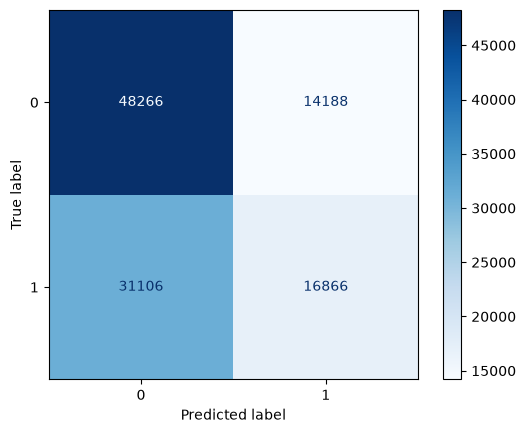

In [390]:
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    grid_search,      # Your fitted GridSearchCV or Pipeline object
    X_test, 
    y_test,
    cmap='Blues',     # Color map palette
    normalize=None    # Set to 'true' for proportions instead of raw counts
)

cnf_matrix = confusion_matrix(y_test, gini_predict)
print(cnf_matrix)
accuracy_gini = model_pipeline.score(X_test,y_test)
print(accuracy_gini)

In [338]:
cv_scores_test= cross_val_score(model_pipeline,X_test,y_test,cv=5,scoring='roc_auc')
cv_scores_train= cross_val_score(model_pipeline,X_train,y_train,cv=5,scoring='roc_auc')
print(cv_scores_test)
cv_scores_rf_test= cv_scores_test.mean()
cv_scores_rf_train= cv_scores_train.mean()
cv_scores_std_rf= cv_scores_test.std()
print ('Mean cross validation test score: ' +str(cv_scores_rf_test))
print ('Mean cross validation train score: ' +str(cv_scores_rf_train))
print ('Standard deviation in cv scores: ' +str(cv_scores_std_rf))

c:\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[0.61334268 0.621267   0.62410606 0.62668103 0.64202455]
Mean cross validation test score: 0.6254842652690027
Mean cross validation train score: 0.6269503109314335
Standard deviation in cv scores: 0.009403364034388137


Without traffic violations

In [ ]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(n_estimators = 300, criterion = 'entropy', max_depth= 15 ,random_state = 42, min_samples_split= 6))
])

model_pipeline.fit(X_train, y_train)
train_accuracy = model_pipeline.score(X_train,y_train)
accuracy = model_pipeline.score(X_test,y_test)
print(train_accuracy)
print(accuracy)

0.5883312984327113
0.5763967315485286


With top 2 traffic violations

In [ ]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(n_estimators = 125, criterion = 'entropy', max_depth= 10 ,random_state = 42, min_samples_split= 5))
])

model_pipeline.fit(X_train, y_train)
train_accuracy = model_pipeline.score(X_train,y_train)
accuracy = model_pipeline.score(X_test,y_test)
print(train_accuracy)
print(accuracy)

0.5960542001301335
0.5958632278320086


In [ ]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(n_estimators = 300, criterion = 'entropy', max_depth= 10 ,random_state = 42, min_samples_split= 5))
])

model_pipeline.fit(X_train, y_train)
train_accuracy = model_pipeline.score(X_train,y_train)
accuracy = model_pipeline.score(X_test,y_test)
print(train_accuracy)
print(accuracy)

0.5958072314334159
0.5952441491537416


With just model filtering and not make filtering

In [339]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('forest', RandomForestClassifier(n_estimators = 125, criterion = 'entropy', max_depth= 15 ,random_state = 42, min_samples_split= 6))
])

model_pipeline.fit(X_train, y_train)
train_accuracy = model_pipeline.score(X_train,y_train)
accuracy = model_pipeline.score(X_test,y_test)
print(train_accuracy)
print(accuracy)

0.6006829393647963
0.5930466622339214


More Metrics (Entropy)

In [340]:
cv_scores_test= cross_val_score(model_pipeline,X_test,y_test,cv=5,scoring='roc_auc')
cv_scores_train= cross_val_score(model_pipeline,X_train,y_train,cv=5,scoring='roc_auc')
print(cv_scores_test)
cv_scores_rf_test= cv_scores_test.mean()
cv_scores_rf_train= cv_scores_train.mean()
cv_scores_std_rf= cv_scores_test.std()
print ('Mean cross validation test score: ' +str(cv_scores_rf_test))
print ('Mean cross validation train score: ' +str(cv_scores_rf_train))
print ('Standard deviation in cv scores: ' +str(cv_scores_std_rf))

c:\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[0.61339561 0.62127492 0.62437484 0.62709905 0.64250912]
Mean cross validation test score: 0.62573070719565
Mean cross validation train score: 0.6270174001121853
Standard deviation in cv scores: 0.009562787703299292


When it comes to selecting a best model to use, it seems inconclusive currently. As all three models are within the same range of each other, which indicates that there is a flaw within the data. A possible reason why I believe this is that I did not properly split up the data as I purpously didn't use all the data at once since the dataset was too large for the computation resources. Therefore, I will need to relook at my datasets and rerun the simulations again.